# Adaptive Zero-Day Network Intrusion Detection using Isolation Forest and Explainable AI

### Project Objective
Detect unusual network traffic using unsupervised anomaly detection
and explain anomalous traffic using Explainable AI.

### Models
- Isolation Forest
- Local Outlier Factor
- One-Class SVM

### Dataset
CICIDS2017

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df1 = pd.read_csv("data/Monday-WorkingHours.pcap_ISCX.csv")
df2 = pd.read_csv("data/Tuesday-WorkingHours.pcap_ISCX.csv")
df3 = pd.read_csv("data/Wednesday-workingHours.pcap_ISCX.csv")
df4 = pd.read_csv("data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df5 = pd.read_csv("data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv("data/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df7 = pd.read_csv("data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df8 = pd.read_csv("data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [3]:
df = pd.concat(
    [df1, df2, df3, df4, df5, df6, df7, df8],
    ignore_index=True
)

In [4]:
df.shape

(2830743, 79)

In [5]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.columns = df.columns.str.strip()

In [7]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [8]:
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [9]:
df = df.replace([np.inf, -np.inf], np.nan)

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
print("Final dataset shape:", df.shape)

Final dataset shape: (2520798, 79)


In [13]:
df.to_csv("data/cleaned_CICIDS2017.csv", index=False) #Save my actual dataset columns, but don't save Pandas' row numbering.”

# EDA

In [14]:
df["Traffic_Type"] = df["Label"].apply(
    lambda x: "Normal" if x == "BENIGN" else "Attack"
)

In [15]:
df["Traffic_Type"].value_counts()

Traffic_Type
Normal    2095057
Attack     425741
Name: count, dtype: int64

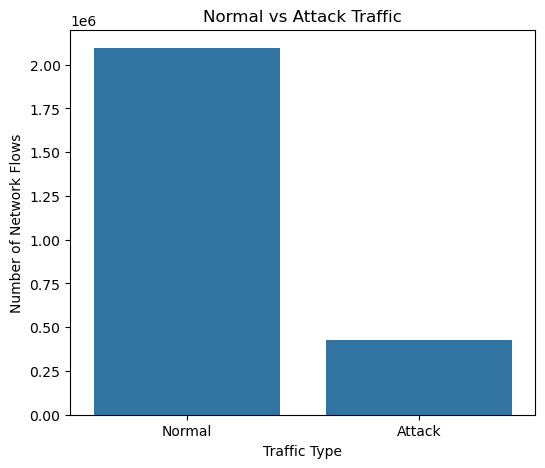

In [16]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="Traffic_Type")

plt.title("Normal vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Network Flows")

plt.show()

In [17]:
attack_counts = df[df["Label"] != "BENIGN"]["Label"].value_counts()

attack_counts

Label
DoS Hulk                      172846
DDoS                          128014
PortScan                       90694
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64

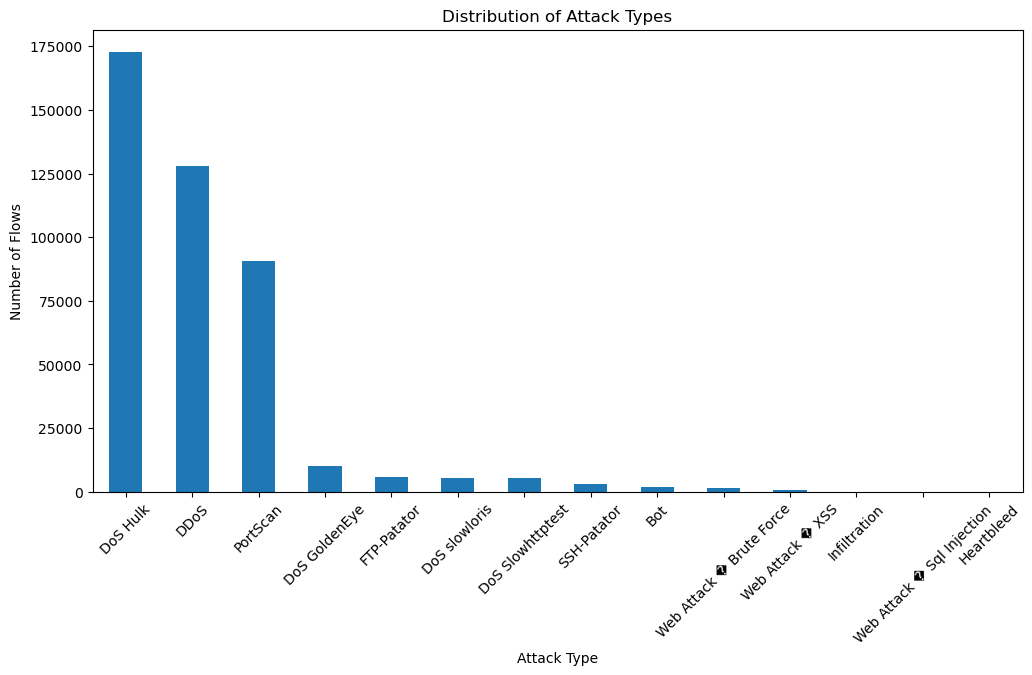

In [18]:
plt.figure(figsize=(12, 6))
attack_counts.plot(kind="bar")

plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Flows")

plt.xticks(rotation=45)
plt.show()

In [19]:
df.dtypes.value_counts()

int64      54
float64    24
object      2
Name: count, dtype: int64

In [20]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(numeric_columns))

Number of numerical features: 78


In [21]:
numeric_columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [22]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2520798.0,8.690590e+03,1.901280e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2520798.0,1.659161e+07,3.523276e+07,-13.0,208.0,50622.0,5333340.5,119999998.0
Total Fwd Packets,2520798.0,1.028174e+01,7.944201e+02,1.0,2.0,2.0,6.0,219759.0
Total Backward Packets,2520798.0,1.157280e+01,1.056922e+03,0.0,1.0,2.0,5.0,291922.0
Total Length of Fwd Packets,2520798.0,6.119477e+02,1.058827e+04,0.0,12.0,66.0,332.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2520798.0,6.546359e+04,6.111585e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2520798.0,9.337367e+06,2.484818e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2520798.0,5.657941e+05,4.874169e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2520798.0,9.763770e+06,2.561746e+07,0.0,0.0,0.0,0.0,120000000.0


In [23]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,2520798.0,1.659161e+07,3.523276e+07,-13.0,208.000000,50622.000000,5.333340e+06,1.200000e+08
Total Fwd Packets,2520798.0,1.028174e+01,7.944201e+02,1.0,2.000000,2.000000,6.000000e+00,2.197590e+05
Total Backward Packets,2520798.0,1.157280e+01,1.056922e+03,0.0,1.000000,2.000000,5.000000e+00,2.919220e+05
Flow Bytes/s,2520798.0,1.410707e+06,2.657084e+07,-261000000.0,119.430792,3715.037858,1.071429e+05,2.071000e+09
Flow Packets/s,2520798.0,4.729188e+04,2.026366e+05,-2000000.0,2.023326,69.742244,1.785714e+04,4.000000e+06


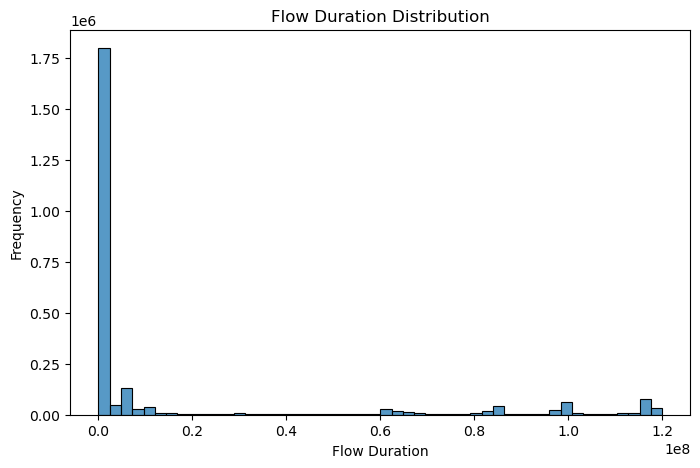

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Flow Duration"],
    bins=50
)

plt.title("Flow Duration Distribution")
plt.xlabel("Flow Duration")
plt.ylabel("Frequency")

plt.show()

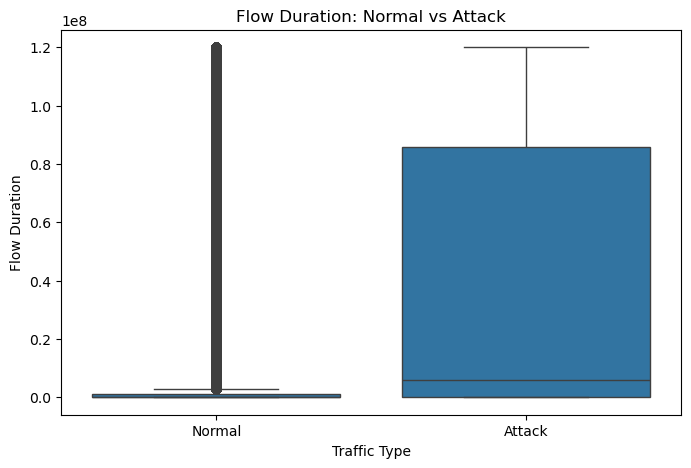

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Traffic_Type",
    y="Flow Duration"
)

plt.title("Flow Duration: Normal vs Attack")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Duration")

plt.show()

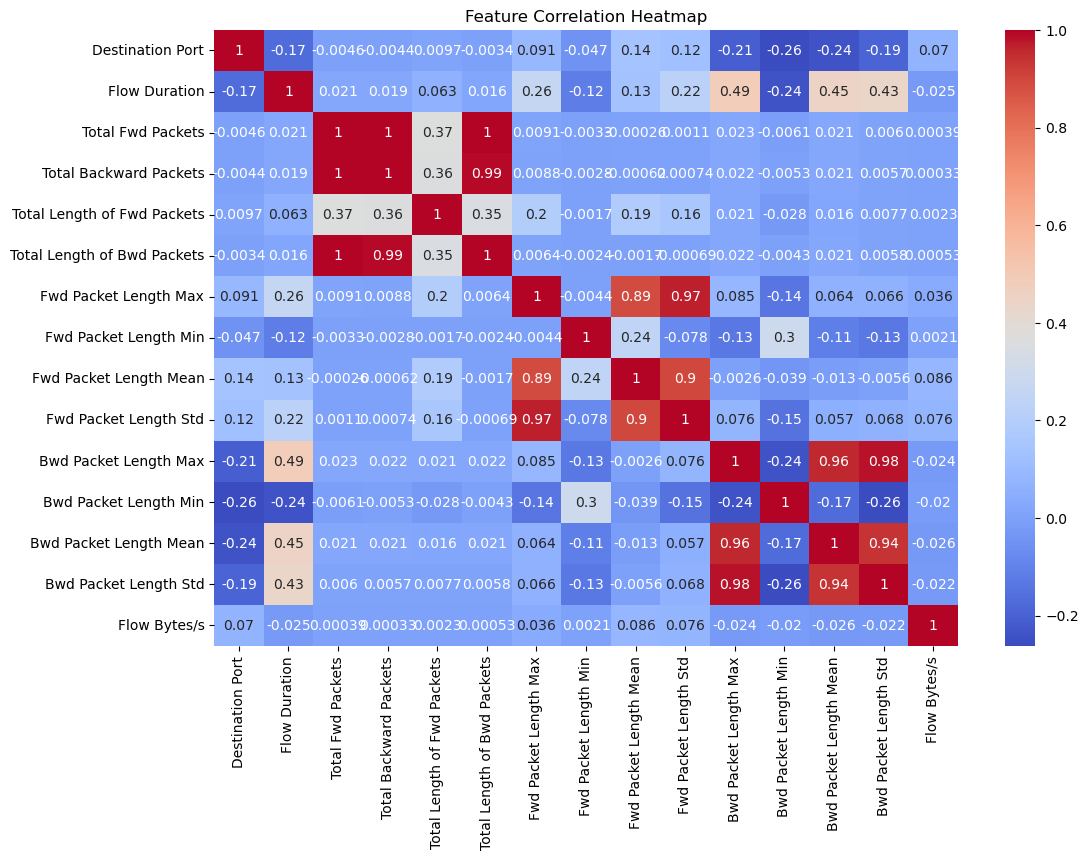

In [26]:
correlation = df[numeric_columns[:15]].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [27]:
correlation_matrix = df[numeric_columns].corr()

high_correlation = correlation_matrix[
    (correlation_matrix.abs() > 0.90) &
    (correlation_matrix.abs() < 1.00)
]

high_correlation

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flow Duration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Fwd Packets,NaN,NaN,NaN,0.99907,NaN,0.996993,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Backward Packets,NaN,NaN,0.99907,NaN,NaN,0.994430,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Length of Fwd Packets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.905749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Idle Mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.990237,0.990079
Idle Std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Idle Max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.990237,NaN,NaN,0.961251


## Check class imbalance

In [28]:
traffic_percentage = (
    df["Traffic_Type"]
    .value_counts(normalize=True) * 100
)
traffic_percentage

Traffic_Type
Normal    83.110864
Attack    16.889136
Name: proportion, dtype: float64

In [29]:
df.to_csv(
    "data/cleaned_CICIDS2017_EDA.csv",
    index=False
)

#  FEATURE ENGINEERING & PREPROCESSING

## Load our cleaned dataset

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/cleaned_CICIDS2017_EDA.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Traffic_Type
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
2,49486,3,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
3,49486,1,2,0,12,0,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal
4,88,609,7,4,484,414,233,0,69.142857,111.967895,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Normal


In [31]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:", df.isnull().sum().sum())

Shape: (2520798, 80)

Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'C

In [32]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

## Separate labels from features

In [33]:
y = df["Traffic_Type"]
X = df.drop(columns=["Label", "Traffic_Type"])

### Remove non-useful identification columns

In [34]:
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

X = X.drop(
    columns=[col for col in columns_to_drop if col in X.columns]
)

print("Remaining features:", X.shape[1])

Remaining features: 78


In [35]:
X = X.apply(pd.to_numeric, errors="coerce") 
#errors="coerce" mean?
#If Pandas finds something that isn't a number, it converts it to: NaN

In [36]:
print("Missing values after conversion:", X.isnull().sum().sum())

Missing values after conversion: 0


In [37]:
X = X.replace([np.inf, -np.inf], np.nan)

In [38]:
X = X.dropna()

In [39]:
valid_rows = X.index
y = y.loc[valid_rows]

In [40]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

### Remove constant features

A feature that has exactly the same value everywhere gives the model no useful information.

In [41]:
constant_columns = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print("Constant columns:", constant_columns)

X = X.drop(columns=constant_columns)

Constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


## Remove duplicate feature columns

In [42]:
duplicate_columns = X.columns[X.columns.duplicated()]

print("Duplicate columns:", duplicate_columns.tolist())

X = X.loc[:, ~X.columns.duplicated()]

Duplicate columns: []


## Separate normal and attack traffic

In [43]:
normal_mask = (y == "Normal") #it creates a true/false mask if y is normal it will show true where this row is normal
#false this row is attack
X_normal = X[normal_mask]
X_attack = X[~normal_mask] #we get only attacks

print("Normal traffic:", X_normal.shape)
print("Attack traffic:", X_attack.shape)

Normal traffic: (2095057, 70)
Attack traffic: (425741, 70)


## Create Normal Training Data

In [44]:
sample_size = min(100000, len(X_normal)) #use atmost 10,000 normal samples

X_train = X_normal.sample( #randomly selects our nrml traffic
    n=sample_size,
    random_state=42
)

print("Training samples:", X_train.shape)
#The features given to the model for learning.

#In our anomaly detection project:

#X_train
#↓
#NORMAL network traffic
#↓
#Model learns what "normal" looks like

Training samples: (100000, 70)


## Create our test data

In [45]:
X_test = pd.concat(      #joining remaining nrml + attack, The features we give to the trained model to see how it performs on unseen data.
    [X_normal.drop(X_train.index), X_attack],
    axis=0
)

y_test = pd.concat( #not given to the anomaly detector learning,this is our answer sheet
    [
        pd.Series(["Normal"] * len(X_normal.drop(X_train.index)),
                  index=X_normal.drop(X_train.index).index),
        pd.Series(["Attack"] * len(X_attack),
                  index=X_attack.index)
    ],
    axis=0
)

## Scaling

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (100000, 70)
Testing shape: (2420798, 70)


In [48]:
import joblib

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [49]:
np.save(
    "models/X_train_scaled.npy",
    X_train_scaled
)

np.save(
    "models/X_test_scaled.npy",
    X_test_scaled
)

y_test.to_csv(
    "models/y_test.csv",
    index=False
)

## Phase 4 — Isolation Forest

In [50]:
from sklearn.ensemble import IsolationForest

In [51]:
iso_model = IsolationForest(
    n_estimators=100, #Build 100 decision trees.
    contamination="auto", #This tells Isolation Forest to automatically determine its threshold for identifying anomalies.
    random_state=42
)

In [52]:
iso_model.fit(X_train_scaled) #Here are examples of normal network behavior. Learn from them.

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [53]:
iso_predictions = iso_model.predict(X_test_scaled)

In [54]:
iso_result = np.where(
    iso_predictions == -1, #Is this prediction an anomaly?"
    "Anomaly",
    "Normal"
)

In [55]:
pd.Series(iso_result).value_counts()

Normal     2031782
Anomaly     389016
Name: count, dtype: int64

In [56]:
iso_pred_binary = np.where(
    iso_predictions == -1,
    "Attack",
    "Normal"
)

In [57]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        iso_pred_binary
    )
)

              precision    recall  f1-score   support

      Attack       0.63      0.57      0.60    425741
      Normal       0.91      0.93      0.92   1995057

    accuracy                           0.86   2420798
   macro avg       0.77      0.75      0.76   2420798
weighted avg       0.86      0.86      0.86   2420798



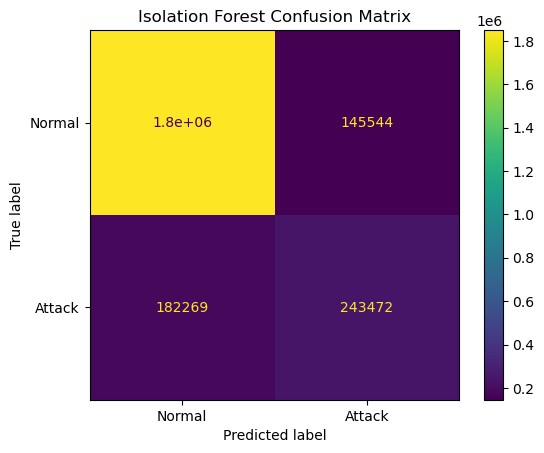

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    iso_pred_binary,
    labels=["Normal", "Attack"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()
plt.title("Isolation Forest Confusion Matrix")
plt.show()

In [59]:
iso_scores = iso_model.decision_function(X_test_scaled) #decision_function() gives each network flow a score.

print(iso_scores[:10])

[0.12320494 0.09683226 0.12021548 0.09704334 0.13918343 0.09609538
 0.07843291 0.06929666 0.13865424 0.07843291]


In [60]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": iso_pred_binary,
    "Anomaly_Score": iso_scores
})

results.head()

,Actual,Prediction,Anomaly_Score
0,Normal,Normal,0.123205
1,Normal,Normal,0.096832
2,Normal,Normal,0.120215
3,Normal,Normal,0.097043
4,Normal,Normal,0.139183


In [61]:
results.sort_values(
    "Anomaly_Score"
).head(10)

,Actual,Prediction,Anomaly_Score
1283557,Normal,Attack,-0.288611
987394,Normal,Attack,-0.275909
1288567,Normal,Attack,-0.274336
26276,Normal,Attack,-0.273180
20170,Normal,Attack,-0.272191
664281,Normal,Attack,-0.271964
1149337,Normal,Attack,-0.271609
2008339,Normal,Attack,-0.270448
312181,Normal,Attack,-0.270127
640907,Normal,Attack,-0.269986


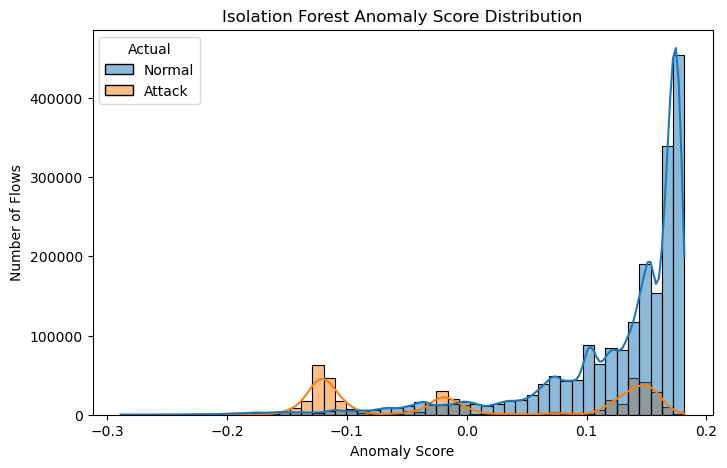

In [62]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=results,
    x="Anomaly_Score",
    hue="Actual",
    bins=50,
    kde=True
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flows")
plt.show()

## Prepare XGBoost labels

In [63]:
print(y.value_counts())

Traffic_Type
Normal    2095057
Attack     425741
Name: count, dtype: int64


### convert the labels into numbers:

In [64]:
y_xgb = y.map({
    "Normal": 0,
    "Attack": 1
})

## Split the data

In [65]:
from sklearn.model_selection import train_test_split

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_xgb
)

In [66]:
from xgboost import XGBClassifier

In [67]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [68]:
xgb_model.fit(
    X_train_xgb, #XGBoost, study the training data and learn the difference between Normal and Attack traffic
    y_train_xgb
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [69]:
xgb_predictions = xgb_model.predict(X_test_xgb)

In [70]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_xgb,
        xgb_predictions,
        target_names=["Normal", "Attack"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    419012
      Attack       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



In [71]:
xgb_results = pd.DataFrame({
    "Actual": y_test_xgb,
    "Prediction": xgb_predictions
})

xgb_results.head()

,Actual,Prediction
359418,0,0
1356791,0,0
557657,1,1
1053797,1,1
2066110,0,0


In [72]:
xgb_probabilities = xgb_model.predict_proba(X_test_xgb)

In [73]:
xgb_attack_probability = xgb_probabilities[:, 1]

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_accuracy = accuracy_score(y_test_xgb, xgb_predictions)
xgb_precision = precision_score(y_test_xgb, xgb_predictions)
xgb_recall = recall_score(y_test_xgb, xgb_predictions)
xgb_f1 = f1_score(y_test_xgb, xgb_predictions)

print("XGBoost Accuracy :", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall   :", xgb_recall)
print("XGBoost F1-score :", xgb_f1)

XGBoost Accuracy : 0.9989328784512853
XGBoost Precision: 0.9964909398178575
XGBoost Recall   : 0.9971931225630667
XGBoost F1-score : 0.9968419075348095


## LSTM Autoencoder

In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

In [76]:
X_normal.shape #(rows, features)

(2095057, 70)

In [77]:
lstm_sample_size = min(50000, len(X_normal))

In [78]:
X_lstm = X_normal.sample(
    n=lstm_sample_size,
    random_state=42
)

In [79]:
X_lstm_scaled = scaler.transform(X_lstm)

In [80]:
X_lstm_scaled.shape

(50000, 70)

### Create sequences

In [81]:
timesteps = 10 #Each sequence will contain 10 consecutive network flows.

In [82]:
num_sequences = len(X_lstm_scaled) // timesteps #50,000 flows ÷ 10 = 5,000 sequences

In [83]:
X_lstm_scaled = X_lstm_scaled[
    :num_sequences * timesteps
]

In [84]:
X_lstm_sequences = X_lstm_scaled.reshape(
    num_sequences,
    timesteps,
    X_lstm_scaled.shape[1]
)

In [85]:
print(X_lstm_sequences.shape)

(5000, 10, 70)


## An Autoencoder has two main parts:

<pre>Input
  ↓
ENCODER
  ↓
Compressed representation
  ↓
DECODER
  ↓
Reconstructed Input

In [86]:
lstm_autoencoder = Sequential()

In [87]:
lstm_autoencoder.add(
    LSTM(
        64, #64 small learning cells that learn patterns from our network traffic.
        activation="tanh", #tanh helps the LSTM control the values it learns.
        input_shape=(timesteps, X_lstm_sequences.shape[2]), #input_shape=(10, 78)
        return_sequences=False #summarizes the entire sequence into one compressed representation.
    )
)

## Decoder

In [88]:
lstm_autoencoder.add(
    RepeatVector(timesteps)
)

In [89]:
lstm_autoencoder.add(
    LSTM(
        64,
        activation="tanh",
        return_sequences=True
    )
) #This LSTM takes the repeated representation and starts reconstructing the sequence.

## Final output layer

In [90]:
lstm_autoencoder.add(
    TimeDistributed(
        Dense(X_lstm_sequences.shape[2])
    )
)

In [91]:
lstm_autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          34,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 10, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 10, 70)              │           4,550 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,134 (281.77 KB)

 Trainable params: 72,134 (281.77 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
lstm_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

In [93]:
history = lstm_autoencoder.fit(
    X_lstm_sequences,
    X_lstm_sequences,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.8746 - val_loss: 0.6908
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.8473 - val_loss: 0.6753
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.8318 - val_loss: 0.6583
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.8083 - val_loss: 0.6397
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7851 - val_loss: 0.6220
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.7566 - val_loss: 0.5979
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.7312 - val_loss: 0.5812
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.7043 - val_loss: 0.5646
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.6834 - val_loss: 0.5526
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.6676 - val_loss: 0.5405


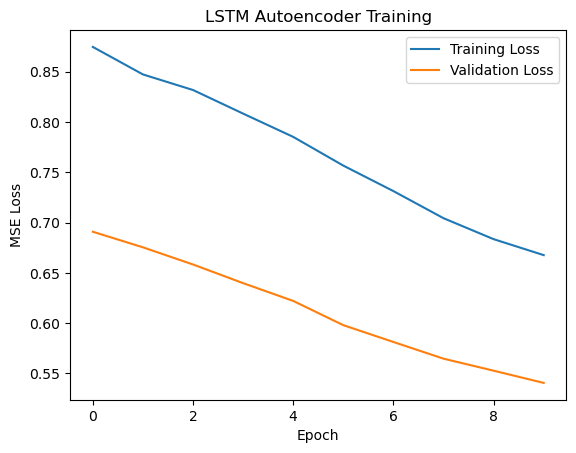

In [94]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training")
plt.legend()
plt.show()

### Reconstruct the training data

In [95]:
X_lstm_reconstructed = lstm_autoencoder.predict(
    X_lstm_sequences
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


### Calculate the error

In [96]:
reconstruction_error = np.mean(
    np.square(
        X_lstm_sequences - X_lstm_reconstructed #Original traffic - Reconstructed traffic
    ),
    axis=(1, 2)
)

In [97]:
print(reconstruction_error[:10])

[0.23621964 1.16840396 0.37493263 1.03324985 0.49608761 0.15106389
 0.38902567 0.25078977 0.17146295 0.23886525]


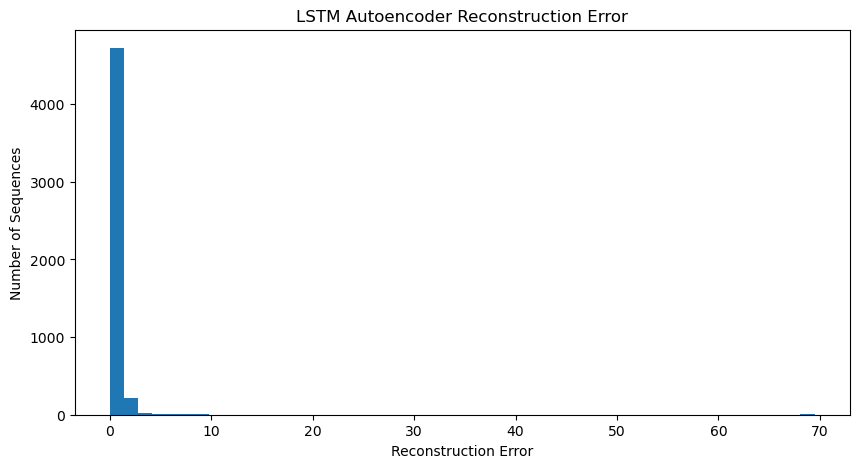

In [98]:
plt.figure(figsize=(10, 5))

plt.hist(
    reconstruction_error,
    bins=50
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Sequences")
plt.title("LSTM Autoencoder Reconstruction Error")

plt.show()

In [99]:
threshold = np.percentile(
    reconstruction_error,
    95
)

print("Anomaly Threshold:", threshold)

Anomaly Threshold: 1.453517883745941


In [100]:
lstm_predictions = np.where(
    reconstruction_error > threshold,
    "Anomaly",
    "Normal"
)

In [101]:
pd.Series(lstm_predictions).value_counts()

Normal     4750
Anomaly     250
Name: count, dtype: int64

In [102]:
print("Normal samples:", len(X_normal))
print("Attack samples:", len(X_attack))

Normal samples: 2095057
Attack samples: 425741


### MULTI-MODEL CONSENSUS

In [103]:
# Number of sequences for evaluation
evaluation_sequences = 2500

# Each sequence contains 10 flows
timesteps = 10

# Number of flows required
evaluation_flows = evaluation_sequences * timesteps

# Sample normal flows
normal_eval = X_normal.sample(
    n=evaluation_flows,
    random_state=100
)

# Sample attack flows
attack_eval = X_attack.sample(
    n=evaluation_flows,
    random_state=100
)

print("Normal evaluation flows:", len(normal_eval))
print("Attack evaluation flows:", len(attack_eval))

Normal evaluation flows: 25000
Attack evaluation flows: 25000


In [104]:
X_eval = pd.concat(
    [normal_eval, attack_eval],
    axis=0
)

y_eval = np.array(
    ["Normal"] * len(normal_eval) +
    ["Attack"] * len(attack_eval)
)

X_eval = X_eval.reset_index(drop=True)

print("Evaluation data shape:", X_eval.shape)

print("\nActual labels:")
print(pd.Series(y_eval).value_counts())

Evaluation data shape: (50000, 70)

Actual labels:
Normal    25000
Attack    25000
Name: count, dtype: int64


In [105]:
X_eval_scaled = scaler.transform(X_eval)

print("Scaled evaluation shape:")
print(X_eval_scaled.shape)

Scaled evaluation shape:
(50000, 70)


In [106]:
iso_eval_predictions = iso_model.predict(
    X_eval_scaled
)

iso_eval_binary = np.where(
    iso_eval_predictions == -1,
    1,
    0
)

print("Isolation Forest predictions:")
print(
    pd.Series(iso_eval_binary).value_counts()
)

Isolation Forest predictions:
0    33918
1    16082
Name: count, dtype: int64


In [107]:
iso_eval_scores = iso_model.decision_function(
    X_eval_scaled
)

print("First 10 Isolation Forest scores:")
print(iso_eval_scores[:10])

First 10 Isolation Forest scores:
[0.16816586 0.08030271 0.17853244 0.02122777 0.1475308  0.15132918
 0.1649219  0.17491264 0.12168231 0.17334534]


In [108]:
xgb_eval_predictions = xgb_model.predict(
    X_eval
)

print("XGBoost predictions:")
print(
    pd.Series(xgb_eval_predictions).value_counts()
)

XGBoost predictions:
0    25053
1    24947
Name: count, dtype: int64


In [109]:
xgb_eval_probabilities = xgb_model.predict_proba(
    X_eval
)

xgb_attack_probability = (
    xgb_eval_probabilities[:, 1]
)

print("First 10 XGBoost attack probabilities:")
print(xgb_attack_probability[:10])

First 10 XGBoost attack probabilities:
[2.3465564e-05 1.9167496e-04 2.8376844e-05 1.1717371e-03 1.0707425e-04
 3.1103755e-05 2.2430153e-05 1.0477502e-04 1.0352772e-04 4.1868500e-03]


In [110]:
num_eval_sequences = len(X_eval_scaled) // timesteps

X_eval_lstm = X_eval_scaled[
    :num_eval_sequences * timesteps
]

X_eval_lstm_sequences = X_eval_lstm.reshape(
    num_eval_sequences,
    timesteps,
    X_eval_scaled.shape[1]
)

print(
    "LSTM evaluation shape:",
    X_eval_lstm_sequences.shape
)

LSTM evaluation shape: (5000, 10, 70)


In [111]:
X_eval_reconstructed = lstm_autoencoder.predict(
    X_eval_lstm_sequences
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [112]:
lstm_eval_error = np.mean(
    np.square(
        X_eval_lstm_sequences -
        X_eval_reconstructed
    ),
    axis=(1, 2)
)

print("First 10 LSTM reconstruction errors:")
print(lstm_eval_error[:10])

First 10 LSTM reconstruction errors:
[0.25107078 0.1910952  0.28861887 0.67273386 0.57717951 0.69373362
 0.94130151 0.12697675 0.58964991 0.57246006]


In [113]:
lstm_eval_predictions = np.where(
    lstm_eval_error > threshold,
    1,
    0
)

print("LSTM predictions:")
print(
    pd.Series(lstm_eval_predictions).value_counts()
)

LSTM predictions:
1    2620
0    2380
Name: count, dtype: int64


In [114]:
actual_sequence_labels = np.array(
    [0] * evaluation_sequences +
    [1] * evaluation_sequences
)

print("Actual sequence labels:")
print(
    pd.Series(actual_sequence_labels).value_counts()
)

Actual sequence labels:
0    2500
1    2500
Name: count, dtype: int64


In [115]:
iso_sequence_predictions = []

for i in range(num_eval_sequences):

    flow_predictions = iso_eval_binary[
        i * timesteps:
        (i + 1) * timesteps
    ]

    if np.sum(flow_predictions) >= 5:
        iso_sequence_predictions.append(1)
    else:
        iso_sequence_predictions.append(0)

iso_sequence_predictions = np.array(
    iso_sequence_predictions
)

print("Isolation Forest sequence predictions:")
print(
    pd.Series(iso_sequence_predictions).value_counts()
)

Isolation Forest sequence predictions:
0    3061
1    1939
Name: count, dtype: int64


In [116]:
xgb_sequence_predictions = []

for i in range(num_eval_sequences):

    flow_predictions = xgb_eval_predictions[
        i * timesteps:
        (i + 1) * timesteps
    ]

    if np.sum(flow_predictions) >= 5:
        xgb_sequence_predictions.append(1)
    else:
        xgb_sequence_predictions.append(0)

xgb_sequence_predictions = np.array(
    xgb_sequence_predictions
)

print("XGBoost sequence predictions:")
print(
    pd.Series(xgb_sequence_predictions).value_counts()
)

XGBoost sequence predictions:
0    2500
1    2500
Name: count, dtype: int64


In [117]:
print("Isolation Forest:")
print(pd.Series(iso_sequence_predictions).value_counts())

print("\nXGBoost:")
print(pd.Series(xgb_sequence_predictions).value_counts())

print("\nLSTM Autoencoder:")
print(pd.Series(lstm_eval_predictions).value_counts())

Isolation Forest:
0    3061
1    1939
Name: count, dtype: int64

XGBoost:
0    2500
1    2500
Name: count, dtype: int64

LSTM Autoencoder:
1    2620
0    2380
Name: count, dtype: int64


In [118]:
consensus_votes = (
    iso_sequence_predictions +
    xgb_sequence_predictions +
    lstm_eval_predictions
)

print("Consensus vote distribution:")
print(
    pd.Series(consensus_votes).value_counts().sort_index()
)

Consensus vote distribution:
0    2358
1     163
2     541
3    1938
Name: count, dtype: int64


In [119]:
consensus_prediction = np.where(
    consensus_votes >= 2,
    1,
    0
)

In [120]:
consensus_labels = np.where(
    consensus_prediction == 1,
    "Attack",
    "Normal"
)

print(
    pd.Series(consensus_labels).value_counts()
)

Normal    2521
Attack    2479
Name: count, dtype: int64


In [121]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_sequence_labels,
        consensus_prediction,
        target_names=[
            "Normal",
            "Attack"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      2500
      Attack       1.00      0.99      1.00      2500

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

consensus_accuracy = accuracy_score(
    actual_sequence_labels,
    consensus_prediction
)

consensus_precision = precision_score(
    actual_sequence_labels,
    consensus_prediction
)

consensus_recall = recall_score(
    actual_sequence_labels,
    consensus_prediction
)

consensus_f1 = f1_score(
    actual_sequence_labels,
    consensus_prediction
)

print("Consensus Accuracy :", consensus_accuracy)
print("Consensus Precision:", consensus_precision)
print("Consensus Recall   :", consensus_recall)
print("Consensus F1-score :", consensus_f1)

Consensus Accuracy : 0.9954
Consensus Precision: 0.99959661153691
Consensus Recall   : 0.9912
Consensus F1-score : 0.9953805985137578


In [123]:
iso_accuracy = accuracy_score(
    actual_sequence_labels,
    iso_sequence_predictions
)

iso_precision = precision_score(
    actual_sequence_labels,
    iso_sequence_predictions
)

iso_recall = recall_score(
    actual_sequence_labels,
    iso_sequence_predictions
)

iso_f1 = f1_score(
    actual_sequence_labels,
    iso_sequence_predictions
)

In [124]:
xgb_accuracy = accuracy_score(
    actual_sequence_labels,
    xgb_sequence_predictions
)

xgb_precision = precision_score(
    actual_sequence_labels,
    xgb_sequence_predictions
)

xgb_recall = recall_score(
    actual_sequence_labels,
    xgb_sequence_predictions
)

xgb_f1 = f1_score(
    actual_sequence_labels,
    xgb_sequence_predictions
)

In [125]:
lstm_accuracy = accuracy_score(
    actual_sequence_labels,
    lstm_eval_predictions
)

lstm_precision = precision_score(
    actual_sequence_labels,
    lstm_eval_predictions
)

lstm_recall = recall_score(
    actual_sequence_labels,
    lstm_eval_predictions
)

lstm_f1 = f1_score(
    actual_sequence_labels,
    lstm_eval_predictions
)

In [126]:
model_comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest",
        "XGBoost",
        "LSTM Autoencoder",
        "Multi-Model Consensus"
    ],

    "Accuracy": [
        iso_accuracy,
        xgb_accuracy,
        lstm_accuracy,
        consensus_accuracy
    ],

    "Precision": [
        iso_precision,
        xgb_precision,
        lstm_precision,
        consensus_precision
    ],

    "Recall": [
        iso_recall,
        xgb_recall,
        lstm_recall,
        consensus_recall
    ],

    "F1 Score": [
        iso_f1,
        xgb_f1,
        lstm_f1,
        consensus_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Isolation Forest,0.8874,0.999484,0.7752,0.873170
1,XGBoost,1.0000,1.000000,1.0000,1.000000
2,LSTM Autoencoder,0.9672,0.945802,0.9912,0.967969
3,Multi-Model Consensus,0.9954,0.999597,0.9912,0.995381


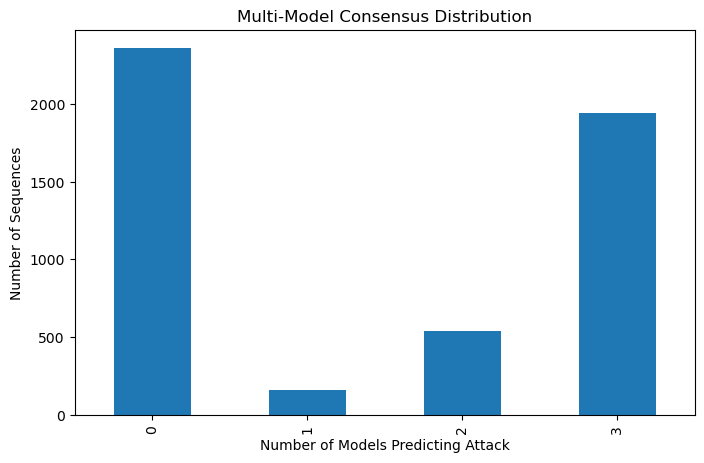

In [127]:
plt.figure(figsize=(8, 5))

pd.Series(
    consensus_votes
).value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Number of Models Predicting Attack")
plt.ylabel("Number of Sequences")
plt.title("Multi-Model Consensus Distribution")

plt.show()

In [128]:
consensus_results = pd.DataFrame({

    "Actual": np.where(
        actual_sequence_labels == 1,
        "Attack",
        "Normal"
    ),

    "Isolation_Forest": np.where(
        iso_sequence_predictions == 1,
        "Attack",
        "Normal"
    ),

    "XGBoost": np.where(
        xgb_sequence_predictions == 1,
        "Attack",
        "Normal"
    ),

    "LSTM_Autoencoder": np.where(
        lstm_eval_predictions == 1,
        "Attack",
        "Normal"
    ),

    "Attack_Votes": consensus_votes,

    "Final_Consensus": consensus_labels
})

consensus_results.head(10)

,Actual,Isolation_Forest,XGBoost,LSTM_Autoencoder,Attack_Votes,Final_Consensus
0,Normal,Normal,Normal,Normal,0,Normal
1,Normal,Normal,Normal,Normal,0,Normal
2,Normal,Normal,Normal,Normal,0,Normal
3,Normal,Normal,Normal,Normal,0,Normal
4,Normal,Normal,Normal,Normal,0,Normal
5,Normal,Normal,Normal,Normal,0,Normal
6,Normal,Normal,Normal,Normal,0,Normal
7,Normal,Normal,Normal,Normal,0,Normal
8,Normal,Normal,Normal,Normal,0,Normal
9,Normal,Normal,Normal,Normal,0,Normal


In [129]:
import os

os.makedirs("reports", exist_ok=True)

print("Reports folder created.")

Reports folder created.


In [130]:
consensus_results.to_csv(
    "reports/multi_model_consensus_results.csv",
    index=False
)

print("Consensus results saved successfully.")

Consensus results saved successfully.


In [131]:
iso_train_scores = iso_model.decision_function(
    X_train_scaled
)

print("Isolation Forest training scores:")
print(iso_train_scores[:10])

Isolation Forest training scores:
[0.16923641 0.16881458 0.01647597 0.14476511 0.13820646 0.12276035
 0.16965192 0.1641134  0.17753655 0.15340482]


In [132]:
iso_train_sorted = np.sort(iso_train_scores)

iso_percentile = np.searchsorted(
    iso_train_sorted,
    iso_eval_scores,
    side="right"
) / len(iso_train_sorted)

iso_risk = (1 - iso_percentile) * 100

iso_risk = np.clip(
    iso_risk,
    0,
    100
)

print("First 10 Isolation Forest risk scores:")
print(iso_risk[:10])

First 10 Isolation Forest risk scores:
[32.22  82.674  5.287 91.316 53.681 50.474 37.24  15.484 68.756 19.433]


### SHAP Explainable AI

In [133]:
import shap

In [134]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)

In [135]:
X_shap = X_test_xgb.sample(
    n=min(1000, len(X_test_xgb)),
    random_state=42
)

In [136]:
shap_values = explainer.shap_values(X_shap)

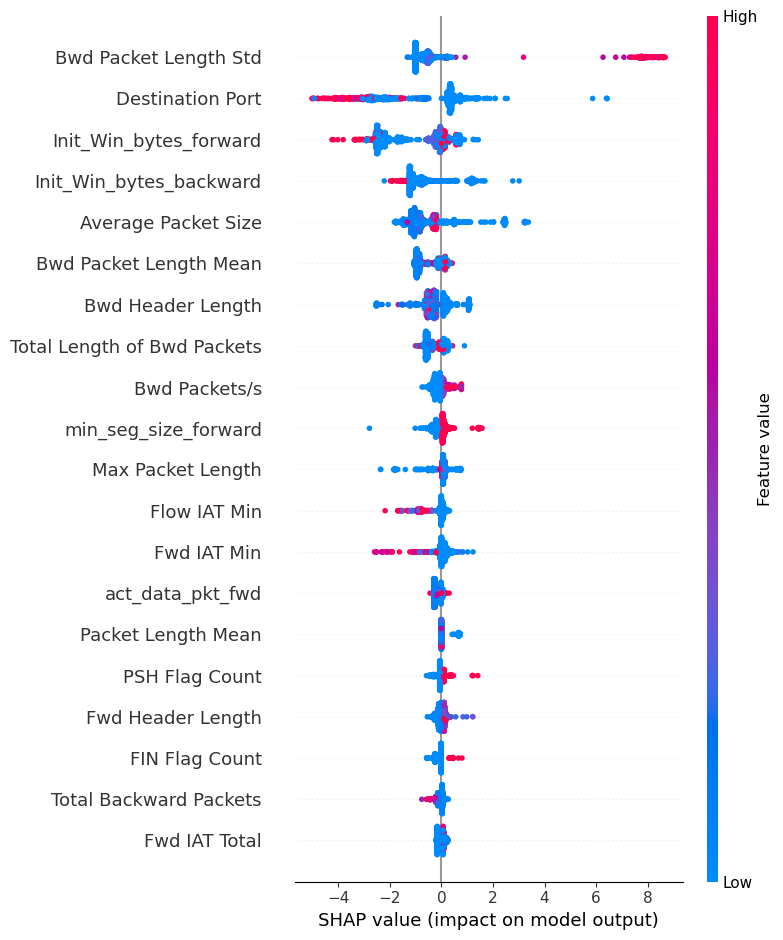

In [137]:
shap.summary_plot(
    shap_values,
    X_shap
)

In [138]:
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Importance",
    ascending=False
)

shap_importance.head(10)

,Feature,Importance
13,Bwd Packet Length Std,1.525778
0,Destination Port,1.419172
58,Init_Win_bytes_forward,1.191556
59,Init_Win_bytes_backward,1.007573
50,Average Packet Size,0.942018
12,Bwd Packet Length Mean,0.538533
33,Bwd Header Length,0.429693
5,Total Length of Bwd Packets,0.369922
35,Bwd Packets/s,0.207383
61,min_seg_size_forward,0.204620


### What-If Risk Simulator

In [139]:
#Pick one flow
sample_flow = X_test_xgb.iloc[[0]].copy()

sample_flow #This selects one network flow from our test data.

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
359418,443,110929,1,1,0,0,0,0,0.0,0.0,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0


In [140]:
#Get its current prediction
original_prob = xgb_model.predict_proba(sample_flow)[0, 1]

print("Original Attack Probability:", round(original_prob * 100, 2), "%")

Original Attack Probability: 0.02 %


In [141]:
#Choose a feature to change
feature = "Flow Bytes/s"

original_value = sample_flow[feature].iloc[0]

print("Original", feature, ":", original_value)

Original Flow Bytes/s : 0.0


In [142]:
what_if_flow = sample_flow.copy()

what_if_flow[feature] = original_value * 2

In [143]:
new_prob = xgb_model.predict_proba(what_if_flow)[0, 1]

print("New Attack Probability:", round(new_prob * 100, 2), "%")

New Attack Probability: 0.02 %


In [144]:
print("Original :", round(original_prob * 100, 2), "%")
print("What-if  :", round(new_prob * 100, 2), "%")

Original : 0.02 %
What-if  : 0.02 %


## Unknown / Novelty Detection

<pre> Known attacks → XGBoost training
                     ↓
             Hidden attack type
                     ↓
              Test the model

In [145]:
df["Label"].value_counts()

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [146]:
unknown_attack = "Heartbleed"

print("Unseen attack:", unknown_attack)

Unseen attack: Heartbleed


In [147]:
unknown_data = df[df["Label"] == unknown_attack]
print("Unknown attack flows:", len(unknown_data))

Unknown attack flows: 11


In [148]:
X_unknown = unknown_data.drop(
    columns=["Label", "Traffic_Type"],
    errors="ignore"
)

X_unknown = X_unknown.drop(
    columns=[col for col in columns_to_drop if col in X_unknown.columns],
    errors="ignore"
)

X_unknown = X_unknown.apply(
    pd.to_numeric,
    errors="coerce"
)

X_unknown = X_unknown.replace(
    [np.inf, -np.inf],
    np.nan
)

X_unknown = X_unknown.dropna()

In [149]:
# Keep exactly the columns used during training
X_unknown = X_unknown[X_train.columns]

# Scale
X_unknown_scaled = scaler.transform(X_unknown)

print(X_unknown_scaled.shape)

(11, 70)


In [150]:
unknown_iso = iso_model.predict(X_unknown_scaled)

print(unknown_iso)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [151]:
unknown_iso_result = np.where(
    unknown_iso == -1,
    "Anomaly",
    "Normal"
)

print(unknown_iso_result)

['Anomaly' 'Anomaly' 'Anomaly' 'Anomaly' 'Anomaly' 'Anomaly' 'Anomaly'
 'Anomaly' 'Anomaly' 'Anomaly' 'Anomaly']


### LSTM prediction

In [152]:
print(
    "Heartbleed detected as anomaly:",
    np.sum(unknown_iso == -1),
    "out of",
    len(unknown_iso)
)

Heartbleed detected as anomaly: 11 out of 11


In [153]:
novelty_result = pd.DataFrame({
    "Attack_Type": ["Heartbleed"],
    "Total_Flows": [len(unknown_iso)],
    "Detected_Anomalies": [np.sum(unknown_iso == -1)]
})

novelty_result["Detection_Rate"] = (
    novelty_result["Detected_Anomalies"] /
    novelty_result["Total_Flows"] * 100
)

novelty_result

,Attack_Type,Total_Flows,Detected_Anomalies,Detection_Rate
0,Heartbleed,11,11,100.0


In [154]:
novelty_result.to_csv(
    "reports/novelty_detection_results.csv",
    index=False
)

In [155]:
import joblib

joblib.dump(iso_model, "models/isolation_forest.pkl")
joblib.dump(xgb_model, "models/xgboost_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [156]:
lstm_autoencoder.save("models/lstm_autoencoder.keras")

print("LSTM model saved successfully!")

LSTM model saved successfully!
